Chia Pei Wang | September 12th, 2026

# Homework 1 — Catching a Bad Run

### Fault Detection & Classification · Multivariate Statistical Process Control

ECE 8803-AI4 · AI for Semiconductor Manufacturing · Fall 2026 · Prof. Asif Khan
· 100 points · Due: \_\_\_\_\_\_\_\_\_\_\_\_

Course website:
<https://aikhan123.github.io/khan-lab-website/ai-semiconductors-course.html>

---

A process step has finished and the tool has logged one sensor channel for
the whole run: two thousand samples, from idle through ramp-up, plateau and
ramp-down. Somebody has to decide whether those wafers move on, using
nothing but the trace. You will build that decision, then find out what it
cannot see.

## The data

One file, `hw1_data.npz`. Every run is a row of 2,000 samples, already
aligned in time, and the three sets are disjoint.

| Array | Shape | What it is |
|---|---|---|
| `baseline_100` | 100 × 2000 | Healthy runs, inspected and accepted. Build your model from these. |
| `scored_100` | 100 × 2000 | Fifty healthy, fifty faulty. Labels in `scored_100_y` (0 healthy, 1 faulty), fault names in `scored_100_type`. |
| `blind_10` | 10 × 2000 | Ten runs, no labels. Six are healthy and four are not. |
| `golden` | 2000 | The nominal recipe trace, noise-free. |

---

**How this notebook works.** Problem 1 is written for you: run the cells in
order and answer the questions. Problem 2 leaves one or two lines blank in
each cell, marked `...` inside a comment block; fill those in and the rest of
the cell runs. Each item repeats its problem statement and then the question,
both word for word from the handout, followed by a note on how to approach
it.

Put your name and the date at the top of whatever you submit.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 10,
    "font.size": 9,
})

NAVY, TEAL, GOLD, RED, GRAY = "#003057", "#008C95", "#A87900", "#A4343A", "#545859"

D = np.load("hw1_data.npz")
print(D.files)

for name in ("baseline_100", "scored_100", "blind_10"):
    print(f"{name:<16}{D[name].shape}")

print(f"\nof the hundred scored runs, {int((D['scored_100_y'] == 1).sum())} are faulty")
print("fault types present:", sorted(set(map(str, D["scored_100_type"])) - {"good"}))

['t', 'golden', 'baseline_100', 'scored_100', 'scored_100_y', 'scored_100_type', 'blind_10', 'fault_names']
baseline_100    (100, 2000)
scored_100      (100, 2000)
blind_10        (10, 2000)

of the hundred scored runs, 50 are faulty
fault types present: ['noise_burst', 'overshoot', 'plateau_droop', 'setpoint_offset', 'slow_ramp', 'spike']


## Look at the data before you model it

Twenty healthy runs and the nominal recipe trace. The run-to-run differences
you can see here are the ones your model has to treat as normal.

The runs are already aligned in time: each one has been shifted so that the
point where it first crosses half of its own rise sits in the same place.
Lecture 1 covers why that matters; it is done for you here.

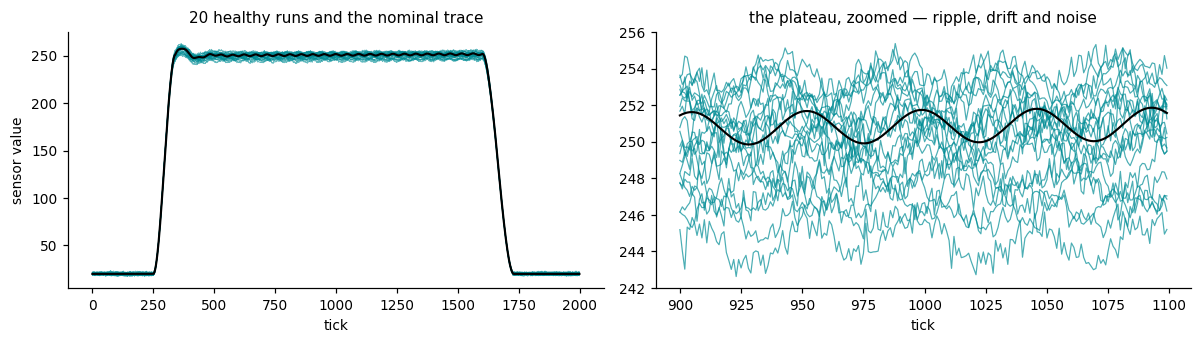

In [2]:
t = D["t"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for y in D["baseline_100"][:20]:
    axes[0].plot(t, y, lw=0.6, alpha=0.6, color=TEAL)
axes[0].plot(t, D["golden"], lw=1.4, color="k")
axes[0].set_xlabel("tick"); axes[0].set_ylabel("sensor value")
axes[0].set_title("20 healthy runs and the nominal trace")

for y in D["baseline_100"][:20]:
    axes[1].plot(t[900:1100], y[900:1100], lw=0.8, alpha=0.7, color=TEAL)
axes[1].plot(t[900:1100], D["golden"][900:1100], lw=1.4, color="k")
axes[1].set_xlabel("tick")
axes[1].set_title("the plateau, zoomed — ripple, drift and noise")
fig.tight_layout()
plt.show()

---
# Problem 1 — Build the monitor &nbsp;·&nbsp; 60 points

The model keeps three components of `baseline_100` and computes two numbers
for every run. The first asks whether the run is an unusual *combination* of
the ingredients healthy runs are made of: a normal-looking shape, present in
an abnormal amount. The second rebuilds the run from the three components
and adds up the square of what will not fit, which asks whether the run
contains a shape the healthy population never produced. Both limits sit at
the ninety-ninth percentile of the baseline scores, and a run is stopped
when either number is above its limit.

## The monitor

Everything the method needs is in the class below. Read it before running it.

`fit` does three things. It takes the mean of the healthy runs, runs one SVD
on the centred matrix to get the components and the variance along each one,
and sets both limits at the ninety-ninth percentile of the baseline's own
scores.

`scores` returns the two numbers per run.

- **T²** projects a run onto the three components and divides each amount by
  the variance the baseline showed along that component before adding them up.
  The division is what makes it a distance: a direction the healthy runs vary
  a lot along has to move a lot before it counts for anything.
- **SPE** rebuilds the run from those three components and adds up the square
  of everything left over. It never looks at the amounts. It asks only whether
  the shape fits.

`residual` returns the leftover tick by tick instead of summed. You will need
it in Problem 2.

In [3]:
class Monitor:
    """PCA baseline, Hotelling's T-squared, and squared prediction error."""

    def __init__(self, k=3, alpha=0.99):
        self.k, self.alpha = k, alpha

    def fit(self, Xgood):
        Xgood = np.asarray(Xgood, float)
        self.mu = Xgood.mean(axis=0)                       # the mean run
        Z = Xgood - self.mu
        U, s, Vt = np.linalg.svd(Z, full_matrices=False)
        self.P = Vt[:self.k].T                             # components, 2000 x k
        self.lam = (s ** 2 / (len(Xgood) - 1))[:self.k]    # variance along each
        self.evr = s ** 2 / (s ** 2).sum()                 # share of the total
        t2, spe = self.scores(Xgood)
        self.t2_lim = np.quantile(t2, self.alpha)          # 99th percentile
        self.spe_lim = np.quantile(spe, self.alpha)
        return self

    def scores(self, X):
        Z = np.asarray(X, float) - self.mu
        T = Z @ self.P                                     # the k amounts
        t2 = (T ** 2 / self.lam).sum(axis=1)
        R = Z - T @ self.P.T                               # what would not fit
        return t2, (R ** 2).sum(axis=1)

    def residual(self, X):
        """Per-tick leftover — the input to a contribution plot."""
        Z = np.asarray(X, float) - self.mu
        return Z - (Z @ self.P) @ self.P.T

    def flag(self, X):
        """True where at least one statistic is above its limit."""
        t2, spe = self.scores(X)
        return (t2 > self.t2_lim) | (spe > self.spe_lim)


def rates(flag, y):
    """Detection rate, false alarm rate and precision, with the counts."""
    flag, y = np.asarray(flag, bool), np.asarray(y, int)
    tp = int((flag & (y == 1)).sum())
    fp = int((flag & (y == 0)).sum())
    fn = int((~flag & (y == 1)).sum())
    return dict(tp=tp, fp=fp, fn=fn,
                dr=tp / max((y == 1).sum(), 1),
                far=fp / max((y == 0).sum(), 1),
                prec=tp / max(tp + fp, 1))

## Item 1.1

**Problem 1 — Build the monitor · 60 points**

> The model keeps three components of `baseline_100` and computes two
> numbers for every run. The first asks whether the run is an unusual
> *combination* of the ingredients healthy runs are made of: a normal-looking shape, present in an abnormal amount. The second rebuilds the
> run from the three components and adds up the square of what will not
> fit, which asks whether the run contains a shape the healthy population
> never produced. Both limits sit at the ninety-ninth percentile of the
> baseline scores, and a run is stopped when either number is above its
> limit.

---

> **Question 1.1.** Both limits, and how much of the variation the three
> components carry. Read the three components against the mean run and say
> in a sentence each what they describe. One carries most of the variance
> on its own: say which part of the run it moves, and why healthy runs
> differ along it.

What to look at. The first list is the share of the total variation each
component carries. The two limits are the ninety-ninth percentile of the
baseline's own scores, so by construction one of the hundred baseline runs
sits above each of them.

The right-hand panel scales each component by the square root of the
variance along it, which puts all three in sensor units. A curve sitting at
plus two and a half across the plateau means healthy runs differ from each
other by about that much there. Read each curve against the mean run on the
left and ask which part of the recipe it moves: the idle level, the ramp,
the plateau, the ramp-down. Then ask what a tool would have to do
differently from run to run to produce that movement.

In [4]:
Xb = D["baseline_100"].astype(float)
mon = Monitor(k=3).fit(Xb)

print("variance explained by each component (%):", np.round(mon.evr[:6] * 100, 2))
print(f"first three together   : {mon.evr[:3].sum():.1%}\n")
print(f"T-squared limit        : {mon.t2_lim:.2f}")
print(f"SPE limit              : {mon.spe_lim:,.0f}")

variance explained by each component (%): [83.16  3.72  1.32  1.07  1.01  0.83]
first three together   : 88.2%

T-squared limit        : 7.65
SPE limit              : 1,909


**Answer**:

Variance explained by each component (%): [83.16,  3.72,  1.32,  1.07,  1.01,  0.83]

First three together   : 88.2%

T-squared limit        : 7.65

SPE limit              : 1,909

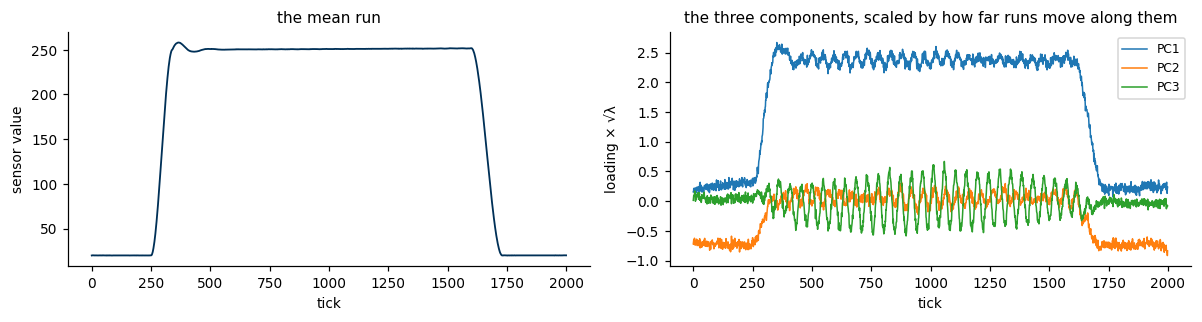

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
axes[0].plot(mon.mu, color=NAVY, lw=1.2)
axes[0].set_xlabel("tick"); axes[0].set_ylabel("sensor value")
axes[0].set_title("the mean run")

for j in range(3):
    axes[1].plot(mon.P[:, j] * np.sqrt(mon.lam[j]), lw=1.0, label=f"PC{j+1}")
axes[1].set_xlabel("tick"); axes[1].set_ylabel("loading × √λ")
axes[1].legend(fontsize=8)
axes[1].set_title("the three components, scaled by how far runs move along them")
fig.tight_layout()
plt.show()

**Answer**:

PC1 - Ordinary healthy run-to-run changes

PC2 - Contrast the plateau with the idle parts

PC3 - Ripple during the plateau

## Item 1.2

**Problem 1 — Build the monitor · 60 points**

> The model keeps three components of `baseline_100` and computes two
> numbers for every run. The first asks whether the run is an unusual
> *combination* of the ingredients healthy runs are made of: a normal-looking shape, present in an abnormal amount. The second rebuilds the
> run from the three components and adds up the square of what will not
> fit, which asks whether the run contains a shape the healthy population
> never produced. Both limits sit at the ninety-ninth percentile of the
> baseline scores, and a run is stopped when either number is above its
> limit.

---

> **Question 1.2.** The detection rate, the false alarm rate and the
> precision on `scored_100`, each as a count and a percentage, with each
> defined in your own words. The limits were set to stop one healthy run
> in a hundred; compare that against what you measured and say what could
> cause the difference.

What to look at. Each rate is a count over a count, and the three
denominators are different. Detection rate divides by the faulty runs. False
alarm rate divides by the healthy runs. Precision divides by the runs the
monitor stopped, whatever they turned out to be.

That last denominator is the one that behaves differently. Detection rate
and false alarm rate are properties of the detector and do not change if you
feed it a set with more faults in it. Precision does. This set is half
faulty by construction, which is generous compared with a real tool.

For the second half of the question: the limit was set on the same hundred
runs the model was fitted to. Ask what that does to the score of a run the
model has never seen. Fifty healthy runs also measure a rate in steps of two
per cent, which is worth mentioning.

In [6]:
Xs = D["scored_100"].astype(float)
ys = D["scored_100_y"]
types = D["scored_100_type"]

t2s, spes = mon.scores(Xs)
flag_s = mon.flag(Xs)
r1 = rates(flag_s, ys)

n_bad, n_good = int((ys == 1).sum()), int((ys == 0).sum())
print(f"detection rate    {r1['tp']}/{n_bad}   = {r1['dr']:.1%}")
print(f"false alarm rate  {r1['fp']}/{n_good}   = {r1['far']:.1%}")
print(f"precision         {r1['tp']}/{r1['tp'] + r1['fp']}   = {r1['prec']:.1%}")
print(f"\nmissed            {r1['fn']} faulty runs")

detection rate    43/50   = 86.0%
false alarm rate  1/50   = 2.0%
precision         43/44   = 97.7%

missed            7 faulty runs


**Answer:**

Detection rate    43/50   = 86.0% (How many actual faults did the monitor catch?)

False alarm rate  1/50   = 2.0% (How many healthy runs did the monitor stop?)

Precision         43/44   = 97.7% (When the monitor stops a run, how often is it correct?)

Missed            7 faulty runs

The nominal threshold used to set the baseline limit should give 1% false alarm rate. However, the measured false alarm rate is 2%.

Possible cause: The 50 healthy runs might be atypical compared to the 100 healthy runs that are used to fit PCA.

## Item 1.3

**Problem 1 — Build the monitor · 60 points**

> The model keeps three components of `baseline_100` and computes two
> numbers for every run. The first asks whether the run is an unusual
> *combination* of the ingredients healthy runs are made of: a normal-looking shape, present in an abnormal amount. The second rebuilds the
> run from the three components and adds up the square of what will not
> fit, which asks whether the run contains a shape the healthy population
> never produced. Both limits sit at the ninety-ninth percentile of the
> baseline scores, and a run is stopped when either number is above its
> limit.

---

> **Question 1.3.** From the scatter and the per-fault-type table: name
> the fault type T² catches on its own and explain why the leftover stays
> small for it; say what the fault types SPE catches have in common; and
> work out how many of the fifty faults you would have caught with only
> one of the two statistics.

What to look at. The two dashed lines cut the plane into four quadrants, and
a run's position says which kind of trouble it is in. Write down what each
quadrant means before answering.

For the table, the four columns are exclusive: a faulty run appears in
exactly one of T-squared only, SPE only, both, or missed. To work out what a
single-statistic monitor would have caught, add the column for that
statistic to the both column.

For the first part of the question, look for the fault type whose column
pattern differs from all the others, then think about what that defect does
to the shape of the trace as against the size of it.

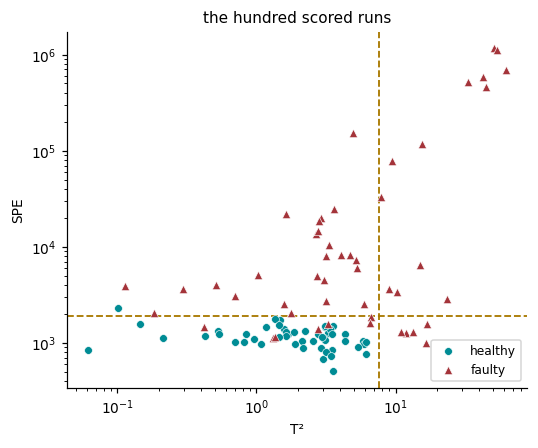

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(t2s[ys == 0], spes[ys == 0], s=26, color=TEAL,
           edgecolor="white", lw=0.4, label="healthy", zorder=3)
ax.scatter(t2s[ys == 1], spes[ys == 1], s=30, color=RED, marker="^",
           edgecolor="white", lw=0.4, label="faulty", zorder=3)
ax.axvline(mon.t2_lim, color=GOLD, ls="--", lw=1.2)
ax.axhline(mon.spe_lim, color=GOLD, ls="--", lw=1.2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("T²"); ax.set_ylabel("SPE")
ax.legend(fontsize=8, loc="lower right")
ax.set_title("the hundred scored runs")
plt.show()

In [8]:
fl_t2 = t2s > mon.t2_lim               # over the T-squared limit
fl_spe = spes > mon.spe_lim            # over the SPE limit

print(f"{'fault type':<18}{'n':>3}{'T² only':>10}{'SPE only':>10}{'both':>7}{'missed':>8}")
print("-" * 56)
for ft in D["fault_names"]:
    sel = types == ft
    a, b = fl_t2[sel], fl_spe[sel]
    print(f"{str(ft):<18}{int(sel.sum()):>3}{int((a & ~b).sum()):>10}"
          f"{int((b & ~a).sum()):>10}{int((a & b).sum()):>7}{int((~a & ~b).sum()):>8}")
print("-" * 56)
print(f"{'healthy':<18}{n_good:>3}{int((fl_t2 & ~fl_spe & (ys == 0)).sum()):>10}"
      f"{int((fl_spe & ~fl_t2 & (ys == 0)).sum()):>10}"
      f"{int((fl_t2 & fl_spe & (ys == 0)).sum()):>7}"
      f"{int((~fl_t2 & ~fl_spe & (ys == 0)).sum()):>8}")

fault type          n   T² only  SPE only   both  missed
--------------------------------------------------------
slow_ramp           9         0         1      8       0
setpoint_offset     9         5         0      1       3
plateau_droop       8         0         4      2       2
overshoot           8         0         7      1       0
spike               8         0         7      1       0
noise_burst         8         0         6      0       2
--------------------------------------------------------
healthy            50         0         1      0      49


The fault type T² catches on its own: setpoint_offset. It shifts the trace in a way that the PCA model can reconstruct, so the SPE remanins small.

The fault types SPE catches: slow_ramp, plateau_droop, overshoot, spike, noise_burst.
What they have in common: all introduce shape, timing, or unmodeled fluctuation that is not well represented by the three PCs.

How many of the fifty faults you would have caught with only one of the two statistics?

T² only - 18/50 = 36%

SPE only - 38/50 = 76%

---
# Problem 2 — The blind ten · 40 points

> Score `blind_10` with the monitor you just built and decide which four
> runs to stop. For the ones you stop, keep the leftover at every sample
> instead of adding it up, and plot it against tick: that plot says where
> in the run the tool departed from what the model expected.
>
> **Worth knowing before you start.** A monitor built from one of the two
> statistics gets some of these right. The second statistic is what tells
> you which ones you would otherwise have missed, and there is no way to
> recover that information after the fact.

`mon` is already fitted and its limits are set; do not refit it. Each cell
below is complete except for one or two lines marked `...`, which are the
lines that answer the question.

In [9]:
Xk = D["blind_10"].astype(float)

## Item 2.1

**Problem 2 — The blind ten · 40 points**

> Score `blind_10` with the monitor you just built and decide which four
> runs to stop. For the ones you stop, keep the leftover at every sample
> instead of adding it up, and plot it against tick: that plot says where
> in the run the tool departed from what the model expected.
>
> **Worth knowing before you start.** A monitor built from one of the two
> statistics gets some of these right. The second statistic is what tells
> you which ones you would otherwise have missed, and there is no way to
> recover that information after the fact.

---

> **Question 2.1.** A table of ten rows: run number, both statistics as
> multiples of their limits, and your verdict.

How to go about it. The two blanks turn each raw statistic into a multiple
of its own limit. Reporting them that way puts the two on the same footing:
above one means out, below one means in, whatever the raw magnitudes are.
Here T-squared runs in single digits while SPE runs in the thousands, so
comparing them any other way would be meaningless.

A run is stopped when either ratio exceeds one; the rest of the cell does
that and prints the table once your two lines are in.

Six of the ten are healthy, so a correct answer stops four. If you stop
three or five, look at how close the borderline run is before deciding your
monitor is wrong.

In [10]:
t2k, spek = mon.scores(Xk)

# ---- write these two lines ------------------------------------------------
# t2_ratio = ...        # T² for each run, as a multiple of mon.t2_lim
# spe_ratio = ...       # SPE for each run, as a multiple of mon.spe_lim
t2_ratio = t2k / mon.t2_lim
spe_ratio = spek / mon.spe_lim
# ---------------------------------------------------------------------------

stopped = (t2_ratio > 1) | (spe_ratio > 1)

print(f"{'run':>4}{'T²/limit':>11}{'SPE/limit':>12}{'verdict':>10}")
print("-" * 37)
for i in range(len(Xk)):
    print(f"{i:>4}{t2_ratio[i]:>11.2f}{spe_ratio[i]:>12.2f}"
          f"{'STOP' if stopped[i] else 'pass':>10}")
print("-" * 37)
print(f"{int(stopped.sum())} of {len(Xk)} runs stopped")

 run   T²/limit   SPE/limit   verdict
-------------------------------------
   0       3.64        0.95      STOP
   1       3.37      268.91      STOP
   2       0.45        0.54      pass
   3       0.90        0.61      pass
   4       0.22        0.58      pass
   5       0.65        5.84      STOP
   6       0.48        0.48      pass
   7       0.31        0.49      pass
   8       0.80        0.53      pass
   9       1.69        0.76      STOP
-------------------------------------
4 of 10 runs stopped


## Item 2.2

**Problem 2 — The blind ten · 40 points**

> Score `blind_10` with the monitor you just built and decide which four
> runs to stop. For the ones you stop, keep the leftover at every sample
> instead of adding it up, and plot it against tick: that plot says where
> in the run the tool departed from what the model expected.
>
> **Worth knowing before you start.** A monitor built from one of the two
> statistics gets some of these right. The second statistic is what tells
> you which ones you would otherwise have missed, and there is no way to
> recover that information after the fact.

---

> **Question 2.2.** For each run you stop, the per-sample leftover plotted
> against tick, and one sentence naming what you think went wrong and
> when.

How to go about it. `mon.residual(Xk)` returns two thousand numbers per run
rather than one. The blank asks for what each of those ticks contributes to
SPE. SPE is the sum of exactly those contributions, which is how you can
check your line: the total the cell prints should equal the SPE you computed
in item 2.1.

The plot uses a symlog vertical scale. On a linear scale one large tick
flattens everything else to zero.

Some of the runs you stopped will show a clear peak and some will be flat
across the whole run. A flat one is an answer, not a failed plot. Say what a
flat contribution plot tells you about where the trouble is.

run 0: largest contribution at tick 1617, 1,821 in total
run 1: largest contribution at tick 1656, 513,421 in total
run 5: largest contribution at tick 959, 11,143 in total
run 9: largest contribution at tick 1057, 1,456 in total


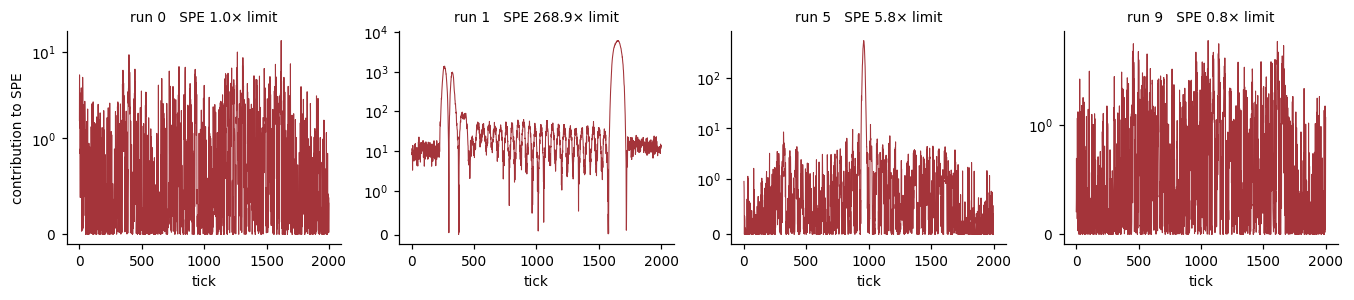

In [11]:
R = mon.residual(Xk)                 # (10, 2000) — the leftover, tick by tick
idx = np.flatnonzero(stopped)

fig, axes = plt.subplots(1, len(idx), figsize=(3.1 * len(idx), 2.8), squeeze=False)
for ax, i in zip(axes[0], idx):
    # ---- write this line --------------------------------------------------
    # contrib = ...     # what each of the 2000 ticks contributes to SPE, run i
    contrib = R[i] ** 2
    # -----------------------------------------------------------------------
    ax.plot(contrib, lw=0.7, color=RED)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("tick")
    ax.set_title(f"run {i}   SPE {spe_ratio[i]:.1f}× limit", fontsize=9)
    print(f"run {i}: largest contribution at tick {int(np.argmax(contrib))}, "
          f"{contrib.sum():,.0f} in total")
axes[0][0].set_ylabel("contribution to SPE")
fig.tight_layout()
plt.show()

## Item 2.3

**Problem 2 — The blind ten · 40 points**

> Score `blind_10` with the monitor you just built and decide which four
> runs to stop. For the ones you stop, keep the leftover at every sample
> instead of adding it up, and plot it against tick: that plot says where
> in the run the tool departed from what the model expected.
>
> **Worth knowing before you start.** A monitor built from one of the two
> statistics gets some of these right. The second statistic is what tells
> you which ones you would otherwise have missed, and there is no way to
> recover that information after the fact.

---

> **Question 2.3.** Some faulty runs are caught by one statistic and
> passed by the other. Identify every such run, say which statistic did
> the work, and explain in physical terms why the other one stayed quiet.

How to go about it. The blank selects the runs where exactly one of the two
ratios from item 2.1 is above one. Everything after it plots each of those
runs against its own rebuild from the three components, and next to it what
the rebuild could not follow.

Those two panels are the explanation. Either the rebuild tracks the run
closely, in which case the leftover is small and SPE has nothing to report,
or it fails to track it, in which case the leftover is large and SPE says
so.

Then answer the physical half. What kind of defect produces a trace the
model can still draw, and what kind produces one it cannot? The answer
should be about the defect, not about the arithmetic.

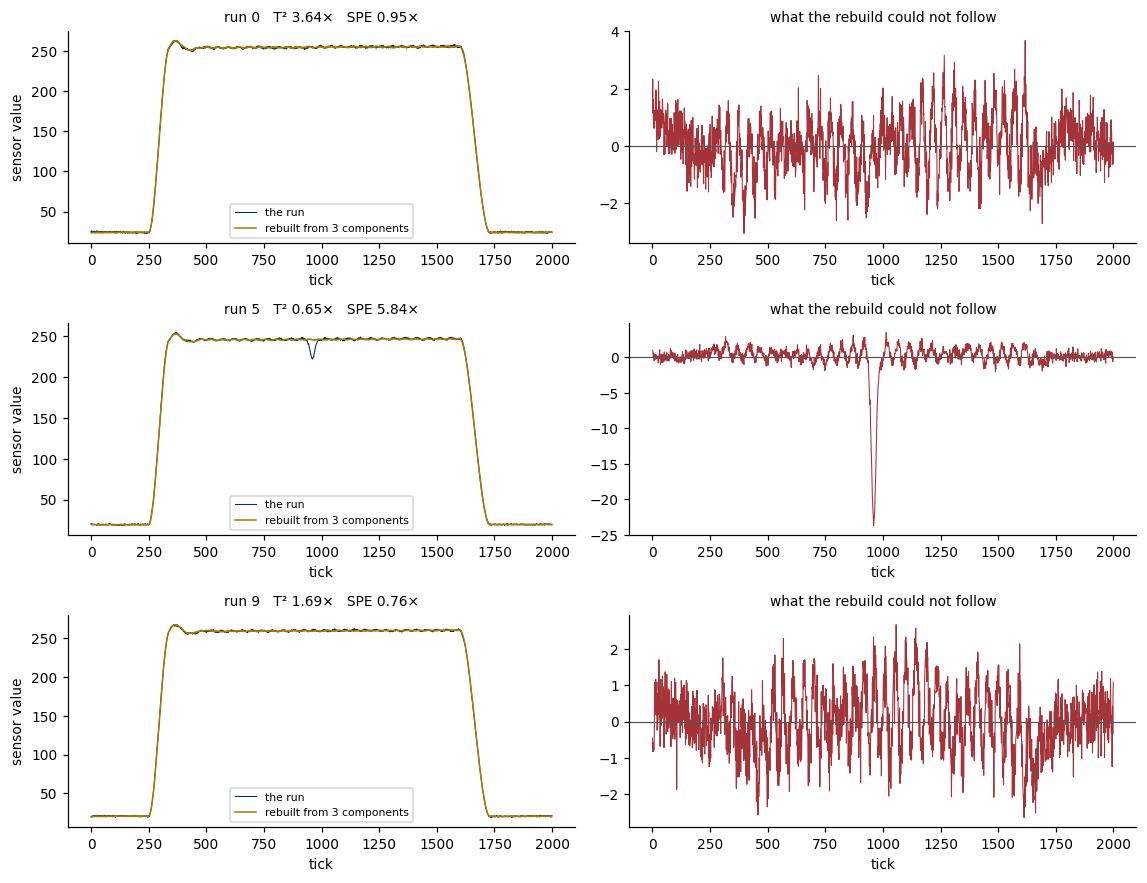

In [12]:
# ---- write this line ------------------------------------------------------
# single = ...      # run numbers where exactly one statistic is above its limit
single = np.flatnonzero((t2_ratio > 1) ^ (spe_ratio > 1))
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(len(single), 2, figsize=(10.5, 2.7 * len(single)),
                         squeeze=False)
for row, i in enumerate(single):
    rebuilt = mon.mu + ((Xk[i] - mon.mu) @ mon.P) @ mon.P.T

    axes[row][0].plot(Xk[i], lw=0.7, color=NAVY, label="the run")
    axes[row][0].plot(rebuilt, lw=1.0, color=GOLD, label="rebuilt from 3 components")
    axes[row][0].set_title(f"run {i}   T² {t2_ratio[i]:.2f}×   "
                           f"SPE {spe_ratio[i]:.2f}×", fontsize=9)
    axes[row][0].set_xlabel("tick"); axes[row][0].set_ylabel("sensor value")
    axes[row][0].legend(fontsize=7)

    axes[row][1].plot(Xk[i] - rebuilt, lw=0.7, color=RED)
    axes[row][1].axhline(0, color=GRAY, lw=0.8)
    axes[row][1].set_title("what the rebuild could not follow", fontsize=9)
    axes[row][1].set_xlabel("tick")
fig.tight_layout()
plt.show()

---
**Submit** one notebook or one PDF, plus the code that produced it, with
labelled axes on every figure. Everyone works from the same data file, so
the same numbers come out for everyone. The credit is in how you explain
them. Discuss the ideas freely and write your own code.